<a href="https://colab.research.google.com/github/Uziii-man/FinGEO-SLM/blob/main/01_data_collection_and_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1: Data Collection and Structurally Faithful Preprocessing
This notebook pulls the raw financial datasets (FinQA for fine-tuning, FinanceBench for evaluation) and applies heuristic layout parsing.
It produces structured Markdown tables, generates CoT prompts, and includes EDA for token-length distributions.

## Environment setup
Install or update data processing, visualization, and tokenization libraries.

In [8]:
%pip -q install "datasets>=2.18.0" "pandas>=2.2.0" "numpy>=1.26.0" "matplotlib>=3.8.0" "seaborn>=0.13.0" "tqdm>=4.66.0" "transformers>=4.40.0"

In [9]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount("/content/drive", force_remount=False)

# Define search locations for the project root
candidate_roots = [
    Path("/content/drive/MyDrive/FinGEO-SLM"),
    Path("/content/FinGEO-SLM"),
    Path.cwd()
]

# Identify PROJECT_ROOT by checking for the 'data/finQA' directory structure
PROJECT_ROOT = Path.cwd()
for p in candidate_roots:
    if p.exists() and (p / "data" / "finQA").exists():
        PROJECT_ROOT = p
        break

os.chdir(PROJECT_ROOT)
print(f"Project root set to: {PROJECT_ROOT}")

def project_path(*parts):
    return str(PROJECT_ROOT.joinpath(*parts))

# Verify the specific file exists
finqa_train = project_path("data", "finQA", "train.json")
if os.path.exists(finqa_train):
    print(f"Confirmed: Found train.json at {finqa_train}")
else:
    print(f"Warning: train.json not found at {finqa_train}. Please check the folder structure.")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root set to: /content/drive/MyDrive/FinGEO-SLM
Confirmed: Found train.json at /content/drive/MyDrive/FinGEO-SLM/data/finQA/train.json


In [16]:
import pandas as pd

# Convert the first 5 samples to a pandas DataFrame for display
display_df = pd.DataFrame(finqa_cot_dataset.select(range(5)))

print("First 5 rows of the preprocessed FinQA dataset:")
display(display_df)

First 5 rows of the preprocessed FinQA dataset:


,pre_text,post_text,table,question,answer,exe_list,formatted_prompt
0,[interest rate to a variable interest rate bas...,[fair value of forward exchange contracts afte...,"[[, october 31 2009, november 1 2008], [fair v...",what is the the interest expense in 2009?,380,"[{'arg1': '100', 'arg2': '100', 'op': 'divide1...",[INST] You are a highly accurate financial AI....
1,"[abiomed , inc ., and subsidiaries notes to co...",[the remaining unrecognized compensation expen...,"[[, number of shares ( in thousands ), weighte...","during the 2012 year , did the equity awards i...",,"[{'arg1': '607', 'arg2': '18.13', 'op': 'multi...",[INST] You are a highly accurate financial AI....
2,[the following table shows annual aircraft fue...,"[as of december 31 , 2018 , we did not have an...","[[year, gallons, average priceper gallon, airc...",what was the total operating expenses in 2018 ...,41932,"[{'arg1': '9896', 'arg2': '23.6%', 'op': 'divi...",[INST] You are a highly accurate financial AI....
3,[the fair value of our grants receivable is de...,"[in the third quarter of 2013 , we sold our sh...","[[( in millions ), dec 282013, dec 292012], [a...",what percentage of total cash and investments ...,53%,"[{'arg1': '14001', 'arg2': '26302', 'op': 'div...",[INST] You are a highly accurate financial AI....
4,"[entergy louisiana , llc management's financia...",[the retail electric price variance is primari...,"[[, amount ( in millions )], [2007 net revenue...",what is the growth rate in net revenue in 2008?,-3.2%,"[{'arg1': '959.2', 'arg2': '991.1', 'op': 'min...",[INST] You are a highly accurate financial AI....


## Imports and helper functions
Utilities for parsing tables and formatting CoT prompts.

In [17]:
import os
import json
import textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")

def format_table_to_markdown(table_data):
    """Converts raw 2D array financial tables into structurally faithful Markdown with NaN handling."""
    if not table_data or len(table_data) == 0:
        return ""
    try:
        headers = table_data[0]
        rows = table_data[1:]
        df = pd.DataFrame(rows, columns=headers)
        # Improvement: Fill empty/dash values with 0 or N/A for consistency
        df = df.replace(['', '-', 'n/a', 'None'], '0')
        return df.to_markdown(index=False)
    except Exception:
        return str(table_data)

def format_cot_prompt(example, tokenizer=None, max_tokens=3500):
    """Formats FinQA into a strict CoT prompt with smart truncation."""
    pre_text = " ".join(example.get("pre_text", []))
    post_text = " ".join(example.get("post_text", []))
    table_context = format_table_to_markdown(example.get("table", []))
    question = example.get("question", "")
    answer = example.get("answer", "")
    exe_list = example.get("exe_list", [])

    # Validation: Skip junk data
    if not question or len(question) < 5:
        return {"formatted_prompt": None}

    reasoning_steps = " -> ".join([
        f"{s.get('op', '')}({s.get('arg1', '')}, {s.get('arg2', '')}) = {s.get('res', '')}"
        for s in exe_list
    ]) if isinstance(exe_list, list) and exe_list and isinstance(exe_list[0], dict) else str(exe_list)

    instruction = "You are a highly accurate financial AI. Use the context and table to answer step-by-step."

    def build_p(pre, post):
        return f"[INST] {instruction}\nContext:\n{pre}\n{post}\n\nFinancial Table:\n{table_context}\n\nQuestion: {question}\n[/INST]\nLet's think step by step.\nReasoning: {reasoning_steps}\nFinal Answer: {answer}"

    full_prompt = build_p(pre_text, post_text)

    # Improvement: Smart Truncation
    if tokenizer and len(tokenizer.encode(full_prompt)) > max_tokens:
        # Priority: Table and Question are kept; pre/post text are truncated
        pre_text = pre_text[:500] + "..."
        post_text = post_text[:500] + "..."
        full_prompt = build_p(pre_text, post_text)

    return {"formatted_prompt": full_prompt}

## Load raw datasets
Read FinQA locally and FinanceBench from the Hugging Face Hub with defensive parsing.

In [11]:
print("Loading datasets...")
finqa_path = project_path("data", "finQA", "train.json")

try:
    with open(finqa_path, "r", encoding="utf-8") as f:
        raw_finqa_data = json.load(f)
except FileNotFoundError as exc:
    raise FileNotFoundError(f"Missing FinQA file at {finqa_path}") from exc
except json.JSONDecodeError as exc:
    raise ValueError("FinQA JSON is malformed") from exc

cleaned_finqa = []
for item in tqdm(raw_finqa_data, desc="Cleaning FinQA", unit="example"):
    qa_data = item.get("qa", {})
    cleaned_finqa.append(
        {
            "pre_text": item.get("pre_text", []),
            "post_text": item.get("post_text", []),
            "table": item.get("table", []),
            "question": qa_data.get("question", ""),
            "answer": str(qa_data.get("answer", "")),
            "exe_list": qa_data.get("exe_list", qa_data.get("steps", [])),
        }
    )

finqa_dataset = Dataset.from_list(cleaned_finqa)

try:
    financebench_dataset = load_dataset("PatronusAI/financebench", split="train")
except Exception as exc:
    raise RuntimeError("Failed to load FinanceBench from the Hub") from exc

print(
    f"FinQA samples: {len(finqa_dataset)} | FinanceBench samples: {len(financebench_dataset)}"
)

Loading datasets...


Cleaning FinQA:   0%|          | 0/6251 [00:00<?, ?example/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

financebench_merged.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/150 [00:00<?, ? examples/s]

FinQA samples: 6251 | FinanceBench samples: 150


## Apply CoT formatting and persist
Map into the final prompt format and save to disk with progress bars.

In [18]:
print("Applying improved CoT formatting...")
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")

# Map with tokenizer passed in for smart truncation
finqa_cot_dataset = finqa_dataset.map(
    lambda x: format_cot_prompt(x, tokenizer=tokenizer),
    desc="Formatting with Smart Truncation"
)

# Filter out any None results from validation
finqa_cot_dataset = finqa_cot_dataset.filter(lambda x: x['formatted_prompt'] is not None)

os.makedirs(project_path("processed_data"), exist_ok=True)
finqa_cot_dataset.save_to_disk(project_path("processed_data", "finqa_cot"))

print(f"Improved preprocessing complete. Final count: {len(finqa_cot_dataset)}")

Applying improved CoT formatting...


Formatting with Smart Truncation:   0%|          | 0/6251 [00:00<?, ? examples/s]

Filter:   0%|          | 0/6251 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/6251 [00:00<?, ? examples/s]

Improved preprocessing complete. Final count: 6251


## EDA: token length distribution
Compute token lengths for formatted prompts and inspect a sample CoT prompt.

Computing token lengths:   0%|          | 0/2000 [00:00<?, ? examples/s]

Token length stats -> min: 313 | max: 3174 | mean: 1268.80


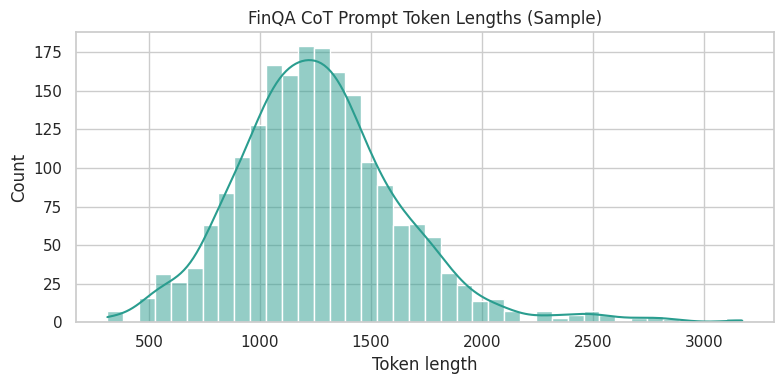

Sample formatted_prompt:

[INST] You are a highly accurate financial AI. Use the context and table to answer step-by-step.
Context: interest rate to a variable interest rate based on the three-month libor plus 2.05% ( 2.05
% ) ( 2.34% ( 2.34 % ) as of october 31 , 2009 ) . if libor changes by 100 basis points , our annual
interest expense would change by $ 3.8 million . foreign currency exposure as more fully described
in note 2i . in the notes to consolidated financial statements contained in item 8 of this annual
report on form 10-k , we regularly hedge our non-u.s . dollar-based exposures by entering into
forward foreign currency exchange contracts . the terms of these contracts are for periods matching
the duration of the underlying exposure and generally range from one month to twelve months .
currently , our largest foreign currency exposure is the euro , primarily because our european
operations have the highest proportion of our local currency denominated expenses . relative to

In [19]:
try:
    tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")
    sample_size = min(2000, len(finqa_cot_dataset))
    eda_sample = finqa_cot_dataset.select(range(sample_size))

    def add_token_length(batch):
        tokenized = tokenizer(batch["formatted_prompt"], add_special_tokens=False)
        return {"token_length": [len(ids) for ids in tokenized["input_ids"]]}

    eda_with_len = eda_sample.map(add_token_length, batched=True, desc="Computing token lengths")
    lengths = eda_with_len["token_length"]

    print(f"Token length stats -> min: {min(lengths)} | max: {max(lengths)} | mean: {np.mean(lengths):.2f}")

    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.figure(figsize=(8, 4))
    sns.histplot(lengths, bins=40, kde=True, color="#2a9d8f")
    plt.title("FinQA CoT Prompt Token Lengths (Sample)")
    plt.xlabel("Token length")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    sample_prompt = finqa_cot_dataset[0]["formatted_prompt"]
    print("Sample formatted_prompt:\n")
    import textwrap
    print(textwrap.fill(sample_prompt, width=100))
except Exception as exc:
    print(f"EDA failed: {exc}")

## Output validation
Run strict checks to confirm preprocessing artifacts and schema were produced correctly.

In [20]:
assert len(finqa_dataset) > 0, "FinQA dataset is empty"
assert len(financebench_dataset) > 0, "FinanceBench dataset is empty"
assert len(finqa_cot_dataset) > 0, "Formatted FinQA dataset is empty"
assert "formatted_prompt" in finqa_cot_dataset.column_names, "formatted_prompt column missing"
assert os.path.exists(project_path("processed_data", "finqa_cot")), "processed_data/finqa_cot not found"
print("Validation complete: Phase 1 notebook executed end-to-end successfully.")

Validation complete: Phase 1 notebook executed end-to-end successfully.
